# 03e — DepthFormer-RGB (Swin-Tiny + PPM)
**Paper:** Ma et al., Earth and Space Science 12, e2024EA003812 (2025). DOI: 10.1029/2024EA003812

**Variante A:** DepthFormer-RGB (sin canal de profundidad, adaptado a AI4MARS).

## 0. Configuración

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import sys; sys.path.append('.')
import torch, torch.nn as nn, torch.nn.functional as F
import pandas as pd, numpy as np
from mars_utils_fast import (
    set_seed, get_or_create_split, build_dataloaders,
    run_multi_seed, append_benchmark_results,
    visualize_predictions, count_parameters,
    NUM_CLASSES, IGNORE_INDEX
)
set_seed()
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
MODEL_NAME = "depthformer_rgb"
try:
    import timm; print(f"timm {timm.__version__} OK")
except ImportError:
    print("pip install timm")


Device: cuda


c:\Users\User\miniconda3\envs\pytorch_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


timm 1.0.26 OK


## 1. Dataset

In [3]:
df = pd.read_csv("processed/manifest_256.csv")
df_train, df_val, df_test = get_or_create_split(df)
train_loader, val_loader, test_loader = build_dataloaders(
    df_train, df_val, df_test, batch_size=16, num_workers=0
)


✅ Split cargado desde processed\split_indices.pkl
Train: 16074 {'MSL': 15901, 'MER': 173}
Val  :  3443 {'MSL': 3443}
Test :  3448 {'MSL': 3448}


## 2. Arquitectura DepthFormer-RGB
Encoder Swin-Tiny (4 etapas) → PPM bottleneck → Decoder multi-escala con element-wise addition.

In [4]:
class PPM(nn.Module):
    """Pyramid Pooling Module con pool sizes [1,2,3,6]."""
    def __init__(self, in_ch, pool_sizes=[1,2,3,6]):
        super().__init__()
        out_ch = in_ch // len(pool_sizes)
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.AdaptiveAvgPool2d(s),
                nn.Conv2d(in_ch, out_ch, 1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(True)
            ) for s in pool_sizes
        ])
        self.fuse = nn.Sequential(
            nn.Conv2d(in_ch + out_ch*len(pool_sizes), in_ch, 1, bias=False),
            nn.BatchNorm2d(in_ch), nn.ReLU(True)
        )
    def forward(self, x):
        parts = [x] + [
            F.interpolate(b(x), size=x.shape[-2:], mode='bilinear', align_corners=False)
            for b in self.branches
        ]
        return self.fuse(torch.cat(parts, dim=1))

class ConvBnRelu(nn.Sequential):
    def __init__(self,i,o,k=1,p=0):
        super().__init__(nn.Conv2d(i,o,k,padding=p,bias=False),nn.BatchNorm2d(o),nn.ReLU(True))

class DepthFormerRGB(nn.Module):
    """
    Encoder: Swin-Tiny (pretrained). Canales: [96,192,384,768].
    Bottleneck: PPM sobre features del stage 4.
    Decoder: Conv1x1 alineación + upsample×2 + element-wise addition.
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.encoder = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=True, features_only=True,
            out_indices=(0,1,2,3),
            img_size=256  
        )
        chs = self.encoder.feature_info.channels()  # [96,192,384,768]

        self.ppm = PPM(chs[3])

        # Alineación de canales para el decoder
        self.align3 = ConvBnRelu(chs[2], chs[3])
        self.align2 = ConvBnRelu(chs[1], chs[3])
        self.align1 = ConvBnRelu(chs[0], chs[3])

        # Decode head
        self.decode = nn.Sequential(
            ConvBnRelu(chs[3], 256, 3, 1),
            nn.Conv2d(256, num_classes, 1)
        )

    def forward(self, x):
        feats = self.encoder(x)
        f1,f2,f3,f4 = [
            feat.permute(0,3,1,2) if feat.dim()==4 else feat
            for feat in feats
        ]

        x4 = self.ppm(f4)

        # Decoder: upsample + element-wise addition
        x3 = F.interpolate(x4, size=f3.shape[-2:], mode='bilinear', align_corners=False)
        x3 = x3 + self.align3(f3)

        x2 = F.interpolate(x3, size=f2.shape[-2:], mode='bilinear', align_corners=False)
        x2 = x2 + self.align2(f2)

        x1 = F.interpolate(x2, size=f1.shape[-2:], mode='bilinear', align_corners=False)
        x1 = x1 + self.align1(f1)

        out = self.decode(x1)
        return F.interpolate(out, size=x.shape[-2:], mode='bilinear', align_corners=False)

def build_depthformer():
    return DepthFormerRGB(NUM_CLASSES)

model = build_depthformer().to(device)
params_M = count_parameters(model)
print(f"Parámetros: {params_M:.2f}M")
with torch.no_grad():
    dummy = torch.randn(2,3,256,256).to(device)
    print(f"Output: {model(dummy).shape}")


Parámetros: 31.58M
Output: torch.Size([2, 4, 256, 256])


## 3. Entrenamiento (3 seeds)
AdamW + PolynomialLR, Weighted CE (pesos adaptados a AI4MARS)

In [5]:
import torch.optim as optim

# Pesos inspirados en el paper, adaptados a distribución AI4MARS
# soil~36%, bedrock~46%, sand~16%, big_rock~2%
CLASS_WEIGHTS = torch.tensor([1.0, 0.8, 2.0, 8.0]).to(device)

def criterion_fn():
    return nn.CrossEntropyLoss(
        weight=CLASS_WEIGHTS,
        ignore_index=IGNORE_INDEX
    )

def optimizer_fn(params):
    return optim.AdamW(params, lr=1e-4, weight_decay=0.01)

def scheduler_fn(opt):
    return optim.lr_scheduler.PolynomialLR(opt, total_iters=30, power=0.9)

summary = run_multi_seed(
    model_fn=build_depthformer,
    df_train=df_train, df_val=df_val, df_test=df_test,
    criterion_fn=criterion_fn, optimizer_fn=optimizer_fn, scheduler_fn=scheduler_fn,
    model_name=MODEL_NAME, device=device,
    seeds=[42,123,7], num_epochs=80, patience=10, batch_size=10, num_workers=6, n_per_mission=700
)



──────────────────────────────────────────────────
  Seed 42 | depthformer_rgb



  depthformer_rgb_seed42 | device=cuda | AMP=True
Ep   1/80 | loss=0.5902 mIoU=0.5117 | val=0.7220 | rock=0.3442
Ep   2/80 | loss=0.3726 mIoU=0.6151 | val=0.6332 | rock=0.1347
Ep   3/80 | loss=0.3260 mIoU=0.6444 | val=0.7359 | rock=0.2757
Ep   4/80 | loss=0.2722 mIoU=0.6720 | val=0.7551 | rock=0.4244
Ep   5/80 | loss=0.2487 mIoU=0.7174 | val=0.7927 | rock=0.4946
Ep   6/80 | loss=0.2206 mIoU=0.7064 | val=0.6920 | rock=0.2600
Ep   7/80 | loss=0.2056 mIoU=0.7299 | val=0.7004 | rock=0.2694
Ep   8/80 | loss=0.2403 mIoU=0.7137 | val=0.7715 | rock=0.4701
Ep   9/80 | loss=0.1685 mIoU=0.7610 | val=0.7577 | rock=0.3563
Ep  10/80 | loss=0.1555 mIoU=0.8002 | val=0.8192 | rock=0.5638
Ep  11/80 | loss=0.1347 mIoU=0.7871 | val=0.8090 | rock=0.4873
Ep  12/80 | loss=0.1336 mIoU=0.8044 | val=0.7655 | rock=0.3460
Ep  13/80 | loss=0.1138 mIoU=0.8450 | val=0.7722 | rock=0.3742
Ep  14/80 | loss=0.1040 mIoU=0.8370 | val=0.7729 | rock=0.4467
Ep  15/80 | loss=0.1012 mIoU=0.8721 | val=0.8005 | rock=0.4794
Ep  

## 4. Guardado y Visualización

In [ ]:
append_benchmark_results(
    model_name=MODEL_NAME, best_epoch=summary["best_epoch_mean"],
    val_miou=summary["mIoU_mean"], test_miou=summary["mIoU_mean"],
    test_miou_std=summary["mIoU_std"], test_miou_ci95=summary["mIoU_ci95"],
    test_acc=summary["pixel_acc_mean"],
    iou_soil=summary["iou_soil_mean"], iou_bedrock=summary["iou_bedrock_mean"],
    iou_sand=summary["iou_sand_mean"], iou_bigrock=summary["iou_big_rock_mean"],
    params_M=params_M, train_time_s=summary["train_time_mean"],
)
best_model = build_depthformer().to(device)
ckpt = torch.load(f"checkpoints/{MODEL_NAME}_seed42_best.pth", map_location=device)
best_model.load_state_dict(ckpt["model_state"])
visualize_predictions(best_model, df_test, device, n=5,
    save_path=f"results/{MODEL_NAME}_predictions.png")
print(f"mIoU: {summary['mIoU_mean']:.4f} ± {summary['mIoU_std']:.4f}")


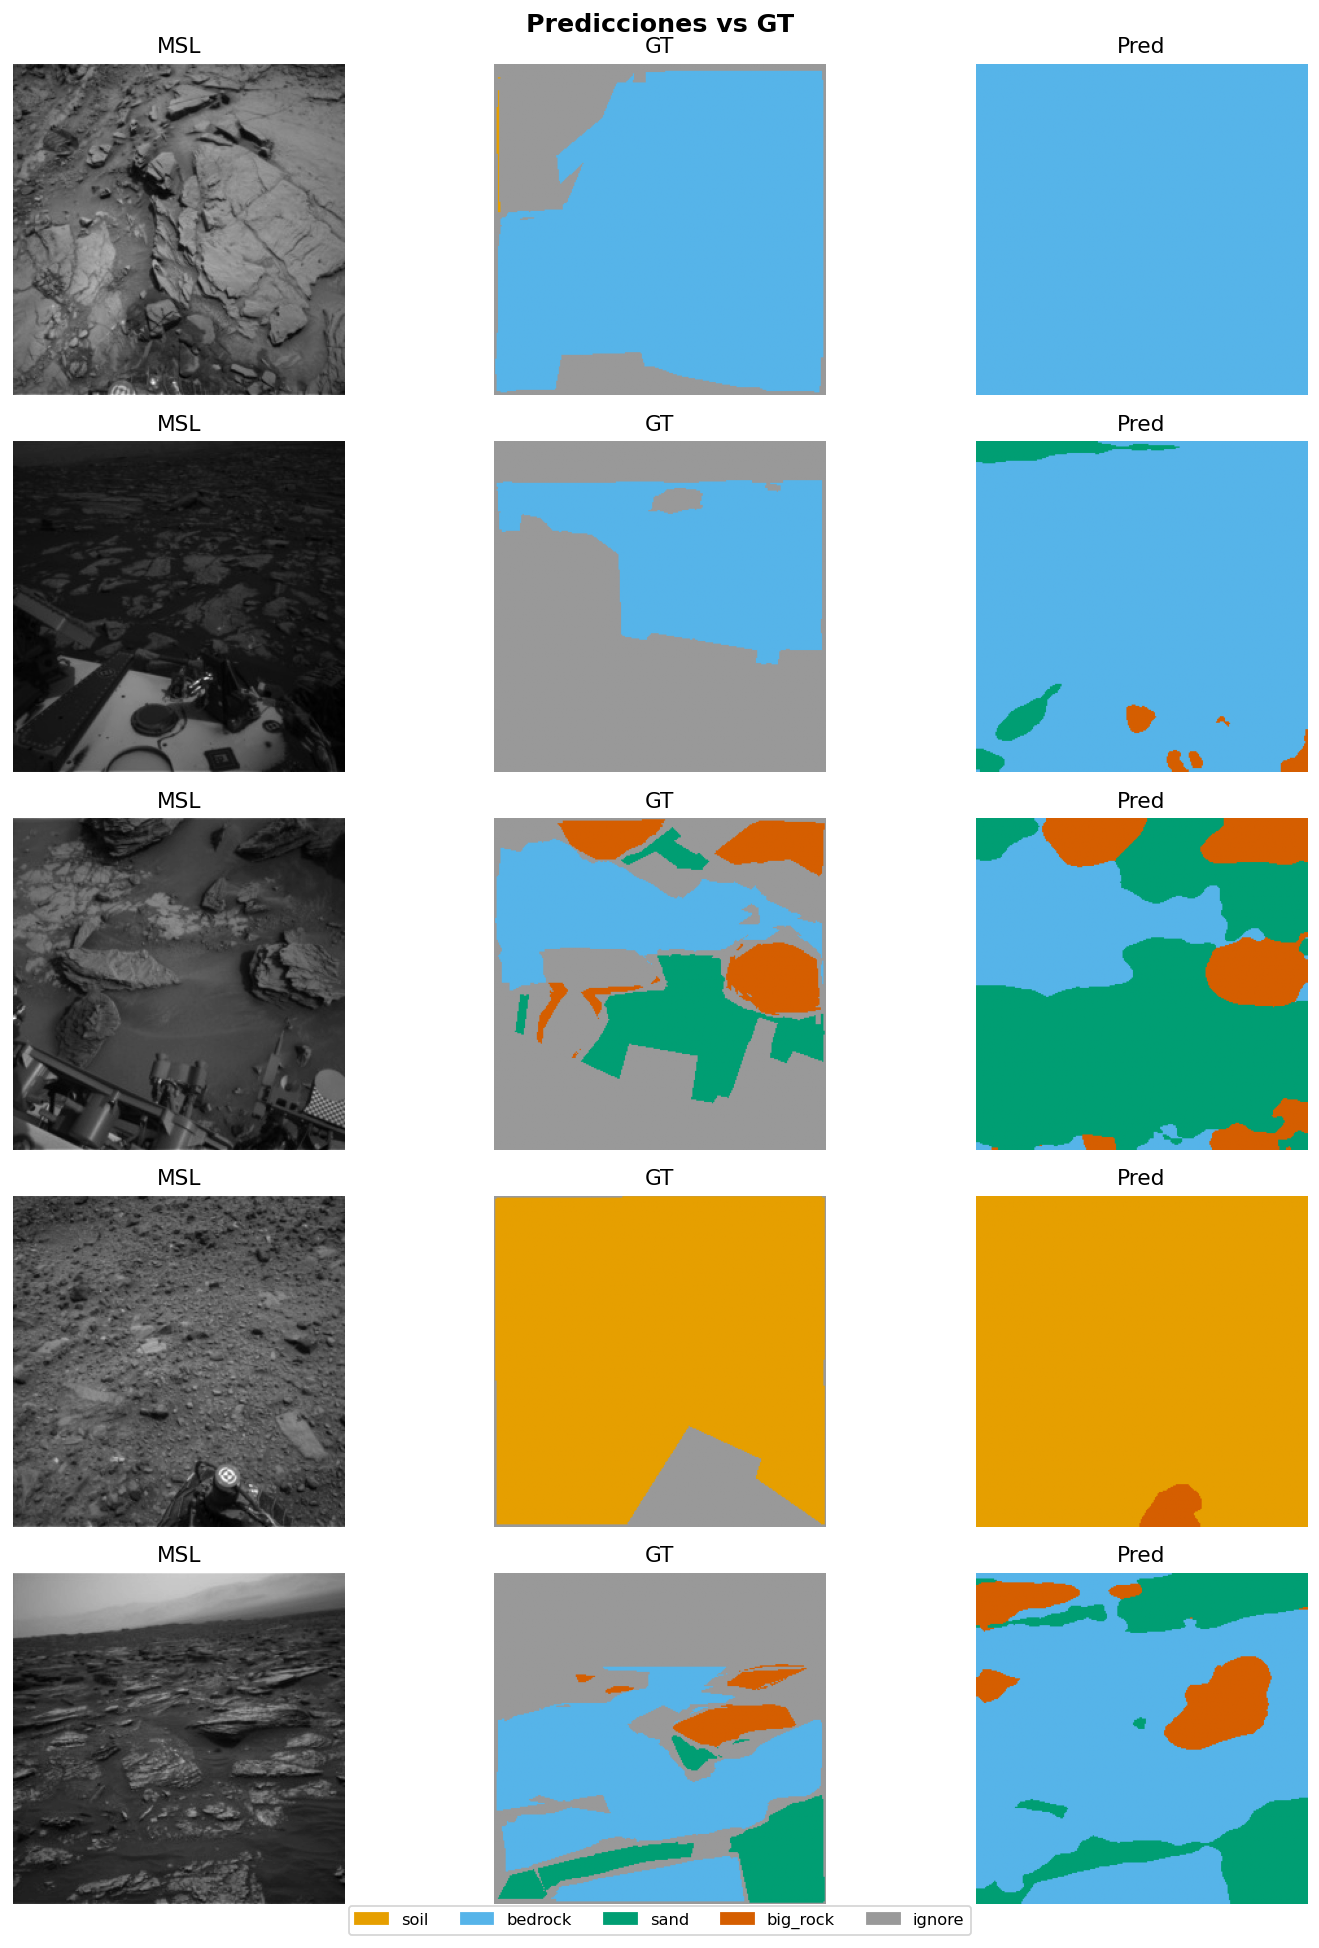